<a href="https://colab.research.google.com/github/Adchayakumar/Final-project/blob/main/model%20training%20files/K_Means_Clustering_with_Optimal_K.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df=pd.read_csv('/content/studentdata_v1.csv')

train_df, holdout_df = train_test_split(df, test_size=0.2, random_state=42)


(200000, 14)

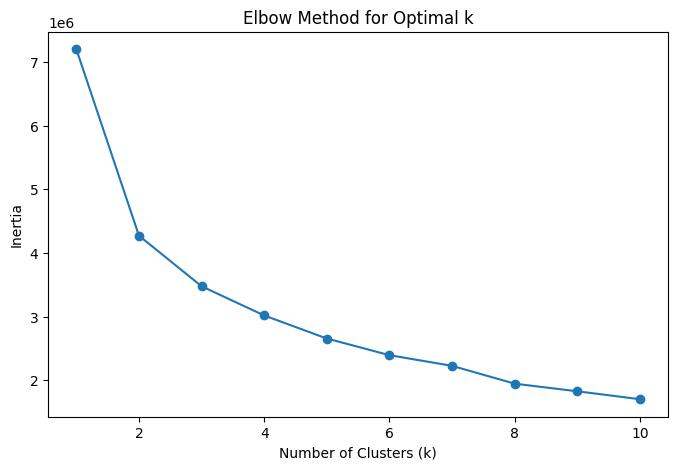

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import joblib



df = train_df.copy()

# 2. Define the features as requested
features = [
    'attendance_rate',
    'homework_completion_rate',
    'past_score',
    'motivation_level',
    'video_time',
    'quiz_time',
    'homework_time',
    'quiz_accuracy',
    'use_ed_tech'
]



# Ensure the DataFrame has only the requested features
df = df[features]

# 3. Preprocessing: Encoding 'use_ed_tech' column
le = LabelEncoder()
df['use_ed_tech'] = le.fit_transform(df['use_ed_tech'])

# 4. Preprocessing: Scaling the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 5. Determine the optimal 'k' value using the Elbow Method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pickle
import warnings
warnings.filterwarnings('ignore')

df = train_df.copy()

# Define the features as requested
features = [
    'attendance_rate',
    'homework_completion_rate',
    'past_score',
    'motivation_level',
    'video_time',
    'quiz_time',
    'homework_time',
    'quiz_accuracy',
    'use_ed_tech'
]

# 1. Preprocess the 'use_ed_tech' column with LabelEncoder
le = LabelEncoder()
df['use_ed_tech'] = le.fit_transform(df['use_ed_tech'])

# Create the feature set (replace the original categorical column with the encoded one)
features_processed = [
    'attendance_rate',
    'homework_completion_rate',
    'past_score',
    'motivation_level',
    'video_time',
    'quiz_time',
    'homework_time',
    'quiz_accuracy',
    'use_ed_tech'
]

X = df[features_processed]

# 2. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA to reduce multicollinearity and dimensionality
# Let's keep enough components to explain 95% of variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Original number of features: {X.shape[1]}")
print(f"Reduced number of components: {X_pca.shape[1]}")
print(f"Explained variance ratio: {sum(pca.explained_variance_ratio_):.4f}")

# 4. Train K-Means with optimal k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X_pca)

# 5. Add cluster labels back to the original dataframe
df['cluster'] = kmeans.labels_

# 6. Evaluate the clustering
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(X_pca, kmeans.labels_)
print(f"Silhouette Score: {silhouette_avg:.4f}")
print(f"Inertia: {kmeans.inertia_:.4f}")

# 7. Save all necessary components for future predictions
# Create a dictionary with all components
model_components = {
    'label_encoder': le,
    'scaler': scaler,
    'pca': pca,
    'kmeans': kmeans,
    'features': features_processed
}

# Save to pickle file
with open('clustering_model_v1.pkl', 'wb') as f:
    pickle.dump(model_components, f)

print("Model and components saved successfully as 'clustering_model.pkl'")





Original number of features: 9
Reduced number of components: 5
Explained variance ratio: 0.9616
Silhouette Score: 0.3048
Inertia: 3208379.9740
Model and components saved successfully as 'clustering_model.pkl'


In [ ]:
# 8. Example of how to use the saved model for new predictions
def predict_cluster(new_data, model_path='clustering_model.pkl'):
    """
    Function to predict cluster for new data using saved model
    """
    # Load the model components
    with open(model_path, 'rb') as f:
        components = pickle.load(f)

    # Extract components
    le = components['label_encoder']
    scaler = components['scaler']
    pca = components['pca']
    kmeans = components['kmeans']
    features = components['features']

    # Preprocess the new data
    new_data = new_data.copy()

    # Encode the 'use_ed_tech' column if present
    if 'use_ed_tech' in new_data.columns:
        new_data['use_ed_tech_encoded'] = le.transform(new_data['use_ed_tech'])

    # Ensure we have the right features in the right order
    new_data = new_data[features]

    # Scale the data
    new_data_scaled = scaler.transform(new_data)

    # Apply PCA
    new_data_pca = pca.transform(new_data_scaled)

    # Predict cluster
    cluster = kmeans.predict(new_data_pca)

    return cluster

In [ ]:
# ----------------------------------------------
# MiniBatch K-means on the full 800 k samples
# ----------------------------------------------
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Load and split data
df = pd.read_csv('/content/studentdata_v1.csv')
train_df, holdout_df = train_test_split(df, test_size=0.2, random_state=42)


# X : your 800 k × d feature matrix (NumPy array or pandas DataFrame)
# k : number of clusters you want (e.g. k=10)

k = 4                      # <--- set your k
batch = 10_00000              # <--- mini-batch size
max_iter = 100               # <--- epochs

# Re-define the features and preprocess the data
features = [
    'attendance_rate',
    'homework_completion_rate',
    'past_score',
    'motivation_level',
    'video_time',
    'quiz_time',
    'homework_time',
    'quiz_accuracy',
    'use_ed_tech'
]

# Assuming 'df' is available from a previous cell (e.g., train_df.copy())
# If not, you would need to load or copy the dataframe here.
df_processed = train_df[features].copy()

# Preprocess the 'use_ed_tech' column with LabelEncoder
le = LabelEncoder()
df_processed['use_ed_tech'] = le.fit_transform(df_processed['use_ed_tech'])

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_processed)

# Apply PCA to reduce dimensionality
pca = PCA(n_components=0.95) # Keep enough components to explain 95% of variance
X_pca = pca.fit_transform(X_scaled)


mbkm = MiniBatchKMeans(
        n_clusters=k,
        batch_size=batch,
        max_iter=max_iter,
        n_init=10,
        random_state=42,
        compute_labels=True   # ensures .labels_ is filled
)

mbkm.fit(X_pca)

# ---- quality metrics ----
inertia   = mbkm.inertia_                    # within-cluster SSE
sil       = silhouette_score(X_pca, mbkm.labels_,
                             sample_size=20_000,  # subsample for speed
                             random_state=42)
davies_bouldin = davies_bouldin_score(X_pca, mbkm.labels_)


print(f"MiniBatch K-means  k={k}")
print(f"Inertia      : {inertia:,.1f}")
print(f"Silhouette   : {sil:.3f}")
print(f"Davies-Bouldin: {davies_bouldin:.3f}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/studentdata_v1.csv'